Standard Neural Networks (NNs) generally fail at solving even simple linear PDEs. PINNs use NNs and incorporate the PDE inside the

loss function, as we will see a few steps later.

In some sense, PINNs are "semi-supervised" meaning that the equation drives the learning process (PINNs are supervised "by the equation").

This repository first shows how NNs fail to learn a simple linear ODE outside the training set.

We train a baseline Neural Network to learn the cosine function for which we, of course, have data.

Then we see this function as the solution to the following differential equation:
$$
\begin{cases}
y'' + y = 0, \\
y(0) = 1, \\
y'(0) = 0
\end{cases}
$$

and use PINNs to solve it.

We import a few packages such as Pytorch, Matplotlib and Numpy:

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import numpy as np
import torch.optim
import matplotlib.pyplot as plt
import torch.autograd

We create our training and test data:

we discretize the interval $[0,2\pi]$ uniformly with 201 points.

Then, we split this interval in train set $[0,5]$, and test set $[5,2\pi]$.

In [22]:
mesh = torch.linspace(0,2*np.pi,201)
cos_mesh = torch.cos(mesh)

Plot of the cosine function on $[0,2\pi]$

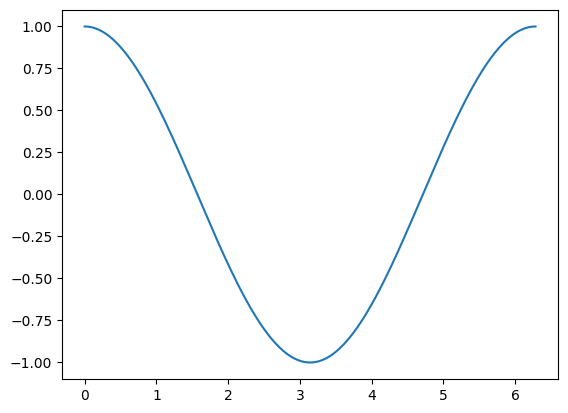

In [23]:
plt.plot(mesh,cos_mesh)
plt.show()

Now we define the mesh on which we are going to learn our NN parameters which is way less dense than the previous one:

In [24]:
mesh_nn = torch.linspace(0,2*np.pi,20)
cos_mesh_nn = torch.cos(mesh_nn)
dataset = torch.stack((mesh_nn,cos_mesh_nn))
nb_train = int(dataset.shape[1]*0.8)
data_train = dataset[:,:nb_train]
data_test = dataset[:,nb_train:]
print(data_train.shape,data_test.shape)

torch.Size([2, 16]) torch.Size([2, 4])


We define our inputs and labels in the getitem method:

In [25]:
class Cosine(Dataset):
    def __init__(self,dataset):
        super().__init__()

        self.dataset = dataset

    def __getitem__(self,idx):
        return self.dataset[0,idx], self.dataset[1,idx]


    def __len__(self):

        return self.dataset.shape[1]   


Regular Neural Network class:

In [26]:
class Neural_Net(nn.Module):
    def __init__(self,nb_layers,input_dim,latent_dim,output_dim,activation):
        super().__init__()

        self.nb_layers = nb_layers
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.output_dim = output_dim
        self.activation = activation
        self.layers = nn.ModuleList([nn.Linear(input_dim,latent_dim)])
        for i in range(self.nb_layers-1):
            self.layers.append(nn.Linear(latent_dim,latent_dim))

        self.last_layer = nn.Linear(latent_dim,output_dim)    

    def forward(self,x):

        inputs = [x]
        for j in range(self.nb_layers):
            a = self.layers[j](inputs[j])
            b = self.activation(a)
            
            inputs.append(b)
        
        output = self.last_layer(inputs[-1])
        return output      


In [27]:
cos_train = Cosine(dataset=data_train)
cos_test = Cosine(dataset=data_test)
BATCH_SIZE = 4
N_EPOCHS = 5000
LR = 1e-3
INPUT_DIM = 1
LATENT_DIM = 20
OUTPUT_DIM = 1
activation = nn.Tanh()
NB_LAYERS = 3
EVERY_EP = 200
ALPHA = 0.1

In [28]:
NN = Neural_Net(nb_layers=NB_LAYERS,input_dim=INPUT_DIM,latent_dim=LATENT_DIM,output_dim=OUTPUT_DIM,activation=activation)

In [29]:
optimizer = torch.optim.Adam(NN.parameters(),lr=LR,weight_decay=1e-4)

In [30]:
train_loader = DataLoader(dataset=cos_train,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
test_loader = DataLoader(dataset=cos_test,batch_size=BATCH_SIZE,shuffle=False,drop_last=False)

We train our baseline NN model with 3000 epochs:

In [31]:
loss_train = 0
l=torch.tensor([0.])
for epoch in range(N_EPOCHS):


    for n_batch,batch in enumerate(train_loader):
        x,labels = batch
        outputs = NN(x.view(BATCH_SIZE,INPUT_DIM))
        
        loss = torch.mean((outputs-labels.view(BATCH_SIZE,INPUT_DIM))**2)
           

        loss_train += loss.detach()
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    loss_train /= (len(train_loader.dataset))
    loss_train *= BATCH_SIZE 
    
    loss_test = 0
    with torch.no_grad():
        for n_batch,batch in enumerate(test_loader):
            a,l =  batch 

            out = NN(a.view(BATCH_SIZE,INPUT_DIM))
            
            Loss = torch.mean((out-l)**2)    
            loss_test += Loss.detach()
        loss_test /= (len(test_loader.dataset)) 
        loss_test *= BATCH_SIZE       
        
        if epoch%EVERY_EP == 0:
            print(f"Epoch: {epoch} , Loss Train: {loss_train}, Loss Test: {loss_test}")



Epoch: 0 , Loss Train: 0.48932456970214844, Loss Test: 0.8277004957199097
Epoch: 200 , Loss Train: 0.01355941966176033, Loss Test: 0.17058414220809937
Epoch: 400 , Loss Train: 0.0008888356387615204, Loss Test: 0.14455264806747437
Epoch: 600 , Loss Train: 0.00020050507737323642, Loss Test: 0.19389331340789795
Epoch: 800 , Loss Train: 0.00026721690664999187, Loss Test: 0.1980922669172287
Epoch: 1000 , Loss Train: 0.0001464469387428835, Loss Test: 0.18221458792686462
Epoch: 1200 , Loss Train: 0.0001111241290345788, Loss Test: 0.18235325813293457
Epoch: 1400 , Loss Train: 8.680702012497932e-05, Loss Test: 0.1942630410194397
Epoch: 1600 , Loss Train: 0.0009763835114426911, Loss Test: 0.19043965637683868
Epoch: 1800 , Loss Train: 0.0004666742170229554, Loss Test: 0.17798900604248047
Epoch: 2000 , Loss Train: 0.0025000623427331448, Loss Test: 0.16600291430950165
Epoch: 2200 , Loss Train: 0.0003469363145995885, Loss Test: 0.17726725339889526
Epoch: 2400 , Loss Train: 0.0004162121331319213, Los

We see here under that the model learns well on the training data, but does not have good performances on the test set.

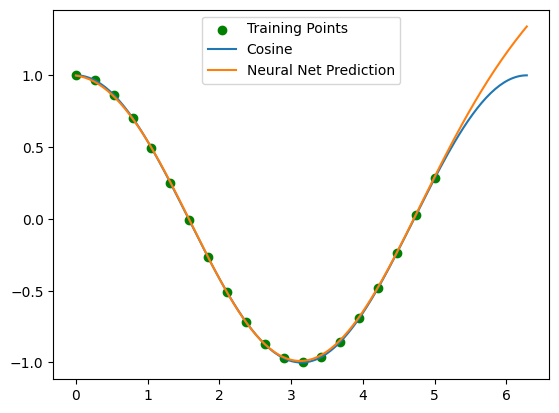

In [32]:
import matplotlib.pyplot as plt

grid = torch.linspace(0,2*np.pi,201).view(201,1)
cos_grid = torch.cos(grid)
y_prediction = NN(grid).detach()
grid_train = torch.linspace(0,5,20).view(20,1)
plt.scatter(grid_train.detach(),torch.cos(grid_train.detach()),color='g',label='Training Points')
plt.plot(grid,cos_grid,label='Cosine')
plt.plot(grid,y_prediction,label='Neural Net Prediction')
plt.legend()



We are now going to learn the Cosine function using a completely different method called

Physics-Informed Neural Networks ($PINNs$):

Consider the following differential equation with two initial conditions:


$y''(x)+ y(x) = 0, x \in [0,2\pi] ,$
            
$y(0) = 1, $
             
$y'(0) = 0$











We know this equation has a unique solution: the cosine.

Neural Networks are universal approximators of continuous functions (on compact sets).

The idea of PINNs is to parameterize $y$ as a Neural Network $y_\theta$ :

thanks to Automatic Differentiation and more particularly the torch.autograd package, we 

can compute the derivative $ \frac{\partial y}{\partial x}$ (that is $y'$), and then $ \frac{\partial^2 y}{\partial x^2}$(that is $y''$) at any point $x$,

 here we choose to evaluate at the points $x_k = \frac{2k\pi}{n} , k \in{0,...,n}$ (and we decide that $n = 14$).

Now let us consider the three following losses:

$L_1 = (y_\theta(0)-1)^2$  

$L_2 = y'_\theta(0)^2$   

$L_3 = (\sum_{k=1}^{n} y''_\theta(x_k) + y_\theta(x_k))^2$ 


Denoting the final loss $L_\theta$, we have:

$L_\theta = \frac{1}{n}(L_1+L_2+L_3)$

and we will minimize $|L_\theta|$ in order to get a solution that respects this differential equation.

In [33]:
Physics_NN = Neural_Net(nb_layers=2,input_dim=1,latent_dim=30,output_dim=1,activation=activation)

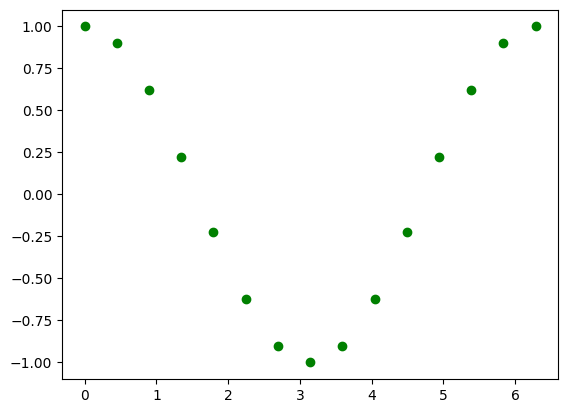

In [34]:
physics_optimizer = torch.optim.Adam(Physics_NN.parameters(),lr=LR)
criterion = nn.MSELoss()
nb_points = 15
x_15 = torch.linspace(0,2*np.pi,nb_points).view(nb_points,1).requires_grad_()
plt.scatter(x_15.detach(),torch.cos(x_15.detach()),color='green')


Here under, we learn the parameters $\theta$ : we expect to get a prediction that respects both the differential equation,

and the initial conditions, thus should give a correct approximation of the cosine.

In [35]:
for ep in range(N_EPOCHS):
    
        
    y = Physics_NN(x_15)
    dy_dx = torch.autograd.grad(y,x_15,torch.ones_like(y),create_graph=True)[0] ###first derivative of y w.r.t x
    
    dy_dxx = torch.autograd.grad(dy_dx,x_15,torch.ones_like(dy_dx),create_graph=True)[0] ### second derivative of y w.r.t x
    loss_ic_y = (y[0]-1)**2   ### ic stands for initial condition, initial condition y(0) = 1
    loss_ic_dy = (dy_dx[0])**2   ### initial condition on the first derivative y'(0) = 0
    loss_physics = (dy_dxx+y)**2    ### we define y''+ y  
    loss = loss_ic_y + loss_ic_dy + torch.mean(loss_physics)
        
    loss.backward()
    physics_optimizer.step()  ### we minimize the sum of loss_physics and the two ic's so that the Differential Equation loss is small and also the IC terms are small
    physics_optimizer.zero_grad()   
     

    if ep%100==0:
        print('loss',loss.item(),'epoch',ep)

loss 1.2281749248504639 epoch 0
loss 0.09625071287155151 epoch 100
loss 0.0857764184474945 epoch 200
loss 0.08049521595239639 epoch 300
loss 0.07121679186820984 epoch 400
loss 0.05956081300973892 epoch 500
loss 0.04678969457745552 epoch 600
loss 0.035569965839385986 epoch 700
loss 0.027502121403813362 epoch 800
loss 0.023586003109812737 epoch 900
loss 0.021652817726135254 epoch 1000
loss 0.020504111424088478 epoch 1100
loss 0.019596589729189873 epoch 1200
loss 0.018732910975813866 epoch 1300
loss 0.017846664413809776 epoch 1400
loss 0.016971943899989128 epoch 1500
loss 0.01605052687227726 epoch 1600
loss 0.014936315827071667 epoch 1700
loss 0.013442493043839931 epoch 1800
loss 0.011537870392203331 epoch 1900
loss 0.009527761489152908 epoch 2000
loss 0.007877277210354805 epoch 2100
loss 0.006372557487338781 epoch 2200
loss 0.004916886333376169 epoch 2300
loss 0.003548759501427412 epoch 2400
loss 0.0023534006904810667 epoch 2500
loss 0.001304197940044105 epoch 2600
loss 0.000599900959059

In the beggining we only had $15$ 'equation' points. Below we discretize more densely ($500$ points).

 We do not see any difference between the true Cosine function and the NN's prediction.

With only $15$ 'equation' points, the Physics-Informed Neural Network method performs very well.

We do not need many points to obtain a good result (at least in dimension $1$).

C:\Users\jamja\AppData\Local\Temp\ipykernel_9956\1249655451.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cos_grid = np.cos(grid)


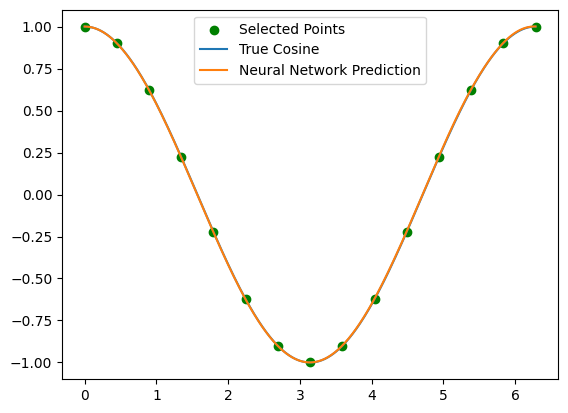

In [36]:
x = torch.linspace(0,2*np.pi,500).view(500,1).requires_grad_()
grid = x.detach()
cos_grid = np.cos(grid)
y = Physics_NN(x)
physics_prediction = y.detach()

plt.scatter(x_15.detach(),torch.cos(x_15.detach()),color='green',label='Selected Points')
plt.plot(grid,cos_grid,label='True Cosine')
plt.plot(grid,physics_prediction,label='Neural Network Prediction')
plt.legend()


We can compute the Mean Squared Error between our $NN$ prediction and the true solution:

the error is around $3.10^{-6}$ which is very low.

In [37]:
print('Mean Square Error',criterion(physics_prediction,torch.cos(grid)).item())

Mean Square Error 5.879931450181175e-06


We can show the  first and second derivative of the cosine against the  

first and second derivative of the NN.
We see that the approximation 

is very good for the first derivative but for the second derivative

oscillations start to appear.

Error on the first derivative: $1.89.10{-5}$ 

Error on the second derivative: $6.10{-4}$

In [38]:
dy_dx_graph = torch.autograd.grad(y,x,torch.ones_like(y),create_graph=True)[0]
dy_dxx_graph = torch.autograd.grad(dy_dx_graph,x,torch.ones_like(dy_dx_graph),create_graph=True)[0]
dy_detach = dy_dx_graph.detach()

C:\Users\jamja\AppData\Local\Temp\ipykernel_9956\507453650.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(grid,-np.sin(grid),label='Negative Sine')
C:\Users\jamja\AppData\Local\Temp\ipykernel_9956\507453650.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(grid,-np.cos(grid),label = 'Negative cosine')


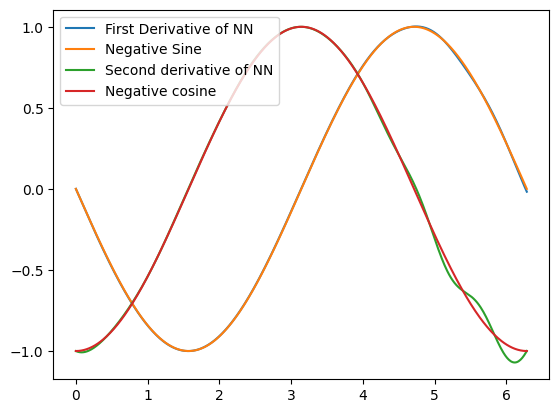

In [39]:
plt.plot(grid,dy_detach,label='First Derivative of NN')
plt.plot(grid,-np.sin(grid),label='Negative Sine')
plt.plot(grid,dy_dxx_graph.detach(),label='Second derivative of NN')
plt.plot(grid,-np.cos(grid),label = 'Negative cosine')
plt.legend()

In [40]:
e1 = criterion(dy_detach,-np.sin(grid))
e2 = criterion(dy_dxx_graph,-np.cos(grid))
print('Error on the first derivative',e1.item())
print('Error on the 2nd derivative',e2.item())

Error on the first derivative 1.8907961930381134e-05
Error on the 2nd derivative 0.0006435648538172245


C:\Users\jamja\AppData\Local\Temp\ipykernel_9956\759927968.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  e1 = criterion(dy_detach,-np.sin(grid))
C:\Users\jamja\AppData\Local\Temp\ipykernel_9956\759927968.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  e2 = criterion(dy_dxx_graph,-np.cos(grid))
